In [ ]:
from google.colab import drive
drive.mount('/content/drive')
folder_path = "drive/MyDrive/Exoplanet Detection/"

Mounted at /content/drive


In [ ]:
import wandb


#log metrics in W&B
run_name = "transformer_12_4_pseudo"


run = wandb.init(
    entity="saiavu-university-of-michigan",
    project="exoplanet-detection",
    name = run_name,
    config={
        "architecture": "Transformer",
        "dataset": "known-labels",
        "epochs": 100,
        "batch_size": 32,
        "learning_rate": 1e-4,
    },
)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: saiavu (deepsensor-greatlakes) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
import torch
import numpy as np
import h5py
from torch.utils.data import Dataset


#class that handles the loading of TESS dataset in H5 format
class TessH5Dataset(Dataset):
    def __init__(self, h5_path, augment=False):
        self.f = h5py.File(h5_path, "r")
        self.global_flux  = self.f["global_flux_view_fluxnorm"]
        self.global_centr = self.f["global_centr_view"]
        self.local_flux   = self.f["local_flux_view_fluxnorm"]
        self.local_centr  = self.f["local_centr_view"]
        self.labels       = self.f["label"]
        self.N = self.labels.shape[0]


    def __len__(self):
        return self.N

    def __getitem__(self, idx):
        # Load raw data
        g_flux = self.global_flux[idx]
        g_cent = self.global_centr[idx]
        l_flux = self.local_flux[idx]
        l_cent = self.local_centr[idx]
        label  = self.labels[idx]

        sample = {
            "global_flux": torch.tensor(g_flux, dtype=torch.float32),
            "global_cent": torch.tensor(g_cent, dtype=torch.float32),
            "local_flux":  torch.tensor(l_flux, dtype=torch.float32),
            "local_cent":  torch.tensor(l_cent, dtype=torch.float32)
        }

        return sample, torch.tensor(label, dtype=torch.long)


In [ ]:
import math
import torch
import torch.nn as nn

#create positional encoding for light curves (trig based)
class PositionalEncoding(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

#1-d convolutional embedding layer
class ConvEmbedding(nn.Module):
    def __init__(self, in_channels=2, hidden=32, d_model=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, hidden, kernel_size=5, padding=2),
            nn.GELU(),
            nn.Conv1d(hidden, hidden, kernel_size=5, padding=2),
            nn.GELU()
        )
        self.proj = nn.Conv1d(hidden, d_model, kernel_size=1)

    def forward(self, x):
        h = self.conv(x)
        h = self.proj(h)
        return h.transpose(1, 2)


def make_encoder(d_model, heads, ff, layers):
    block = nn.TransformerEncoderLayer(
        d_model=d_model,
        nhead=heads,
        dim_feedforward=ff,
        batch_first=True
    )
    return nn.TransformerEncoder(block, num_layers=layers)

#transformer class to combine positional encodings and conv embeddings
class MultiViewTransitTransformer(nn.Module):
    def __init__(self, d_model=128, heads=8, ff=256, layers=2, num_classes=2):
        super().__init__()

        # Local view
        self.local_conv = ConvEmbedding(in_channels=2, d_model=d_model)
        self.local_pos  = PositionalEncoding(d_model)
        self.local_enc  = make_encoder(d_model, heads, ff, layers)

        # Global view
        self.global_conv = ConvEmbedding(in_channels=2, d_model=d_model)
        self.global_pos  = PositionalEncoding(d_model)
        self.global_enc  = make_encoder(d_model, heads, ff, layers)

        #classification head
        self.fc = nn.Sequential(
            nn.Linear(2 * d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, num_classes)
        )

        self.pre_ln = nn.LayerNorm(d_model) #added to deal with exploding gradients

    def encode(self, flux, centr, conv, pos, enc):
        """
        flux, centr: (B, L)
        → returns pooled (B, d_model)
        """
        x = torch.stack([flux, centr], dim=1)
        h = conv(x)         #conv layer
        h = self.pre_ln(h) #norm for exploding gradients
        h = pos(h)          #position encoding
        h = enc(h)
        h, _ = torch.max(h, dim=1)
        return h

    def forward(self, batch):
        gf = batch["global_flux"]
        gc = batch["global_cent"]
        lf = batch["local_flux"]
        lc = batch["local_cent"]

        h_local = self.encode(lf, lc, self.local_conv, self.local_pos, self.local_enc)
        h_global = self.encode(gf, gc, self.global_conv, self.global_pos, self.global_enc)

        h = torch.cat([h_local, h_global], dim=-1) #combine the global and local inputs
        return self.fc(h)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, ConcatDataset
import numpy as np
from tqdm import tqdm
import sklearn.metrics



#create dataset for the pseudo labels for the SSL
class PseudoLabelSubset(Dataset):

    def __init__(self, original_dataset, indices, pseudo_labels):
        self.original_dataset = original_dataset
        self.indices = indices
        self.pseudo_labels = pseudo_labels

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        sample, _ = self.original_dataset[real_idx]
        new_label = self.pseudo_labels[idx]
        return sample, torch.tensor(new_label, dtype=torch.long)



def generate_pseudo_labels(model, unlabeled_dataset, device,
                           planet_thresh=0.95, non_planet_thresh=0.99,
                           balance_ratio=3.0):

    model.eval()
    model.to(device)


    #if hasattr(unlabeled_dataset, 'augment'):
    #    unlabeled_dataset.augment = False

    loader = DataLoader(unlabeled_dataset, batch_size=256, shuffle=False, num_workers=4)
    all_probs = []

    #labeling loop
    with torch.no_grad():
        for batch, _ in tqdm(loader, desc="Scanning Unlabeled Data"):
            batch_dev = {k: v.to(device) for k, v in batch.items()}

            #take care of any NANs in data (since it hasn't been reviewed like labeled data)
            for k in batch_dev:
                batch_dev[k] = torch.nan_to_num(batch_dev[k], nan=0.0, posinf=0.0, neginf=0.0)

            logits = model(batch_dev)
            probs = torch.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())

    all_probs = np.concatenate(all_probs)

    #get indices of planets based on threshold
    idx_planets = np.where(all_probs[:, 1] > planet_thresh)[0]
    #get indices of non-planets based on threshold
    idx_non_planets = np.where(all_probs[:, 0] > non_planet_thresh)[0]

    num_found_planets = len(idx_planets)
   #print(f"{num_found_planets} Planets.")
   #print(f"{len(idx_non_planets) Non-Planets.")


    #handle downsamping
    target_non_planet_count = int(num_found_planets * balance_ratio)

    if target_non_planet_count < len(idx_non_planets):
        selected_non_planets = np.random.choice(idx_non_planets, size=target_non_planet_count, replace=False)
    else:
        selected_non_planets = idx_non_planets


    final_indices = np.concatenate([idx_planets, selected_non_planets])
    labels_p = np.ones(len(idx_planets), dtype=np.longlong)
    labels_np = np.zeros(len(selected_non_planets), dtype=np.longlong)
    final_labels = np.concatenate([labels_p, labels_np])

    return PseudoLabelSubset(unlabeled_dataset, final_indices, final_labels)



def create_mixed_dataloader(original_dataset, pseudo_dataset, batch_size=64):



    combined_dataset = ConcatDataset([original_dataset, pseudo_dataset])

    print(f"Original Size: {len(original_dataset)} | Pseudo Size: {len(pseudo_dataset)}")
    print(f"Combined Training Size: {len(combined_dataset)}")

    return DataLoader(
        combined_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )


def train_one_epoch(model, loader, optimizer, device, epoch_idx, wandb_run=None):
    model.train()
    total_loss = 0

    for batch_idx, (batch_x, batch_y) in enumerate(tqdm(loader, desc=f"Epoch {epoch_idx}", leave=False)):
        #clean data
        for k in batch_x:
            batch_x[k] = batch_x[k].to(device)
            batch_x[k] = torch.nan_to_num(batch_x[k], nan=0.0, posinf=0.0, neginf=0.0)

            if not torch.isfinite(batch_x[k]).all():
                raise ValueError(f"Found non-finite values in input '{k}'")

        batch_y = batch_y.to(device)

        # Forward pass
        logits = model(batch_x)

        #error handling for debugging
        if not torch.isfinite(logits).all():
            raise ValueError("Non-finite logits")

        loss = F.cross_entropy(logits, batch_y)

        if not torch.isfinite(loss):
            raise ValueError("Non-finite loss")

        # Backward prop
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

        if wandb_run:
            wandb_run.log({"batch_loss": loss.item()})

    return total_loss / len(loader)

#call when eval on test set and training
def evaluate(model, loader, device, pos_label=1):
    model.eval()
    all_targets = []
    all_probs = []
    total_loss = 0.0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for batch_x, batch_y in loader:
            for k in batch_x:
                batch_x[k] = batch_x[k].to(device)
                batch_x[k] = torch.nan_to_num(batch_x[k], nan=0.0, posinf=0.0, neginf=0.0)

            batch_y = batch_y.to(device)

            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            total_loss += loss.item()

            probs = torch.softmax(logits, dim=1)[:, pos_label]
            all_targets.extend(batch_y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_targets = np.array(all_targets)
    all_probs = np.array(all_probs)

    preds = (all_probs > 0.5).astype(int)
    accuracy = np.mean(preds == all_targets)


    pr_auc = sklearn.metrics.average_precision_score(all_targets, all_probs)


    return {
        "loss": total_loss / len(loader),
        "accuracy": accuracy * 100,
        "pr_auc": pr_auc,
        "recall": sklearn.metrics.recall_score(all_targets, preds, average= None),
        "precision": sklearn.metrics.precision_score(all_targets, preds, average = None)
    }

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {DEVICE} device")

model = MultiViewTransitTransformer(
    d_model=128,
    heads=8,
    ff=256,
    layers=2,
    num_classes=2).to(DEVICE)

Using cuda device


In [ ]:
model.load_state_dict(torch.load(folder_path + "models/transformer_12_2_augment_model.ckpt"))

<All keys matched successfully>

In [ ]:
UNLABELED_PATH = folder_path + "/tess_lightcurves_unk.h5"

In [ ]:
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

planet_class_id = 1


train_ds = TessH5Dataset(folder_path + "tess_lightcurves_not_unk.h5", augment=True)
#train_ds = TessH5Dataset(folder_path + "tess_lightcurves_not_unk.h5", augment=False

labels = train_ds.labels[:]


N = len(labels)
all_indices = np.arange(N)

#stratified train split
train_idx, temp_idx, _, temp_labels = train_test_split(
    all_indices,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels  # <--- KEY
)

#stratified val split
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

train_ds_split = Subset(train_ds, train_idx)
val_ds = Subset(train_ds, val_idx)
test_ds = Subset(train_ds, test_idx)

train_loader = DataLoader(train_ds_split, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

In [ ]:
# Load unknown
unlabeled_ds = TessH5Dataset(UNLABELED_PATH, augment=False)

pseudo_ds = generate_pseudo_labels(
    model,
    unlabeled_ds,
    DEVICE,
    planet_thresh=0.90,
    non_planet_thresh=0.99,
    balance_ratio=3.0
)

In [ ]:
train_loader = create_mixed_dataloader(
    train_ds_split,
    pseudo_ds,
    batch_size=32 # Matched your batch size
)

In [ ]:
import torch.optim as optim


optimizer = optim.Adam(model.parameters(), lr=1e-5)
EPOCHS = 50


print(f"--- Starting Retraining for {EPOCHS} Epochs ---")

#training loop
for epoch in range(EPOCHS):

    #train for one epoch
    avg_train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=DEVICE,
        epoch_idx=epoch + 1,
        wandb_run= run
    )


    val_metrics = evaluate(
        model=model,
        loader=val_loader,
        device=DEVICE,
        pos_label=1
    )

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.2f}% | "
        f"Val PR-AUC: {val_metrics['pr_auc']:.4f}"
    )

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "val_loss": val_metrics['loss'],
        "val_accuracy": val_metrics['accuracy'],
        "val_pr_auc": val_metrics['pr_auc']
    })

# 4. Save the Final Model
save_path = folder_path + "/models/" + run_name + ".ckpt"
torch.save(model.state_dict(), save_path)
print(f"Training complete. Model saved to {save_path}")


run.finish()

--- Starting Retraining for 50 Epochs ---


Epoch 1/50 | Train Loss: 0.0556 | Val Loss: 0.1338 | Val Acc: 96.43% | Val PR-AUC: 0.8282


Epoch 2/50 | Train Loss: 0.0573 | Val Loss: 0.1158 | Val Acc: 96.86% | Val PR-AUC: 0.8264


Epoch 3/50 | Train Loss: 0.0574 | Val Loss: 0.1354 | Val Acc: 96.34% | Val PR-AUC: 0.8247


Epoch 4/50 | Train Loss: 0.0587 | Val Loss: 0.1422 | Val Acc: 96.37% | Val PR-AUC: 0.8182


...

Epoch 47/50 | Train Loss: 0.0462 | Val Loss: 0.1543 | Val Acc: 97.01% | Val PR-AUC: 0.8302


Epoch 48/50 | Train Loss: 0.0471 | Val Loss: 0.1665 | Val Acc: 96.66% | Val PR-AUC: 0.8285


Epoch 49/50 | Train Loss: 0.0463 | Val Loss: 0.1697 | Val Acc: 96.42% | Val PR-AUC: 0.8134


Epoch 50/50 | Train Loss: 0.0457 | Val Loss: 0.1605 | Val Acc: 96.69% | Val PR-AUC: 0.8251
Training complete. Model saved to drive/MyDrive/Exoplanet Detection//models/transformer_12_4_pseudo.ckpt


batch_loss,▂▁▁▁▁█▁▁▃▄▃▂▁▃▃▁▁▁▃▁▃▂▂▁▁▂▁▂▁▁▂▂▃▁▃▁▁▃▁▁
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
train_loss,▆▇▇██▇▇█▆▇▆▇▆▆▆▆▆▆▅▅▅▄▄▅▄▄▃▄▄▄▃▂▃▃▂▂▂▁▂▁
val_accuracy,▃▆▃▃▁▅▄▅▃▆▆▄▇▅▅▆▇▆▄▂▂▃▅▇▄▅▇▄▅██▆▅▇▃█▆▇▅▅
val_loss,▃▁▃▄▆▃▄▂▅▃▂▄▃▃▅▃▃▃▅█▇▆▅▃▅▄▆▃▅▄▆▇▄▅▇▃▆▅▇▆
val_pr_auc,▅▅▅▄▃▇▂▄▄█▇▇▆▇█▇▆▃▄▇▃▅▄▅▁▃▇▅▆▆▄▅▇▆▃▇▄▆▅▅
batch_loss,0.00012
epoch,50
train_loss,0.04566
val_accuracy,96.68766
val_loss,0.16048


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

model = MultiViewTransitTransformer(
    d_model=128,
    heads=8,
    ff=256,
    layers=2,
    num_classes=2).to(device)

model.load_state_dict(torch.load(folder_path + "models/transformer_12_4_pseudo.ckpt"))



Using cuda device


<All keys matched successfully>

In [ ]:
test_metrics = evaluate(
    model=model,
    loader=test_loader,
    device=DEVICE,
    pos_label=1
)

In [ ]:
test_metrics = evaluate(
    model=model,
    loader=test_loader,
    device=device,
    pos_label=1
)

In [ ]:
test_metrics

{'loss': 0.15557645955851485,
 'accuracy': np.float64(96.8396501457726),
 'pr_auc': np.float64(0.8093089205035957),
 'recall': array([0.97593816, 0.85920578]),
 'precision': array([0.99013408, 0.71150972])}

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score
import numpy as np


model.to(DEVICE)
model.eval()

all_labels = []
all_logits = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        for k in batch_x:
            batch_x[k] = batch_x[k].to(DEVICE)
        batch_y = batch_y.to(DEVICE)

        logits = model(batch_x)

        all_labels.append(batch_y.cpu().numpy())
        all_logits.append(logits.cpu().numpy())

y_true = np.concatenate(all_labels)
all_logits_np = np.concatenate(all_logits)

num_classes = all_logits_np.shape[1]

Test Set PR-AUC for Non-Planet: 0.9986
Test Set PR-AUC for Planet: 0.8110


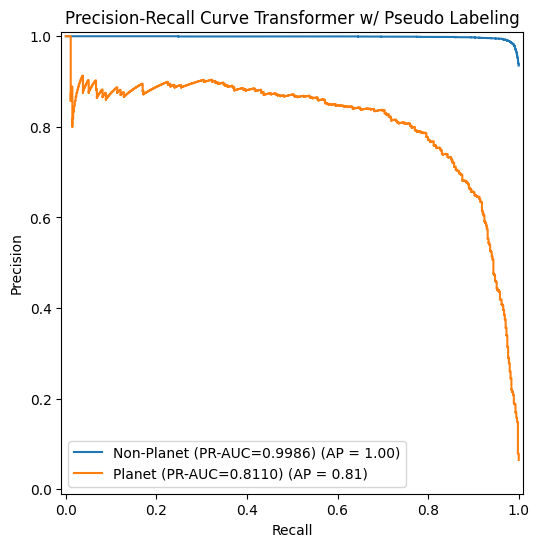

In [ ]:
classes = {0: "Non-Planet", 1: "Planet"}

plt.figure(figsize=(8, 6))
ax = plt.gca()



for i in range(num_classes):
    # Convert true labels to binary
    y_true_bin = (y_true == i).astype(int)

    y_score_class = all_logits_np[:, i]

    pr_auc_score = average_precision_score(y_true_bin, y_score_class)
    print(f"Test Set PR-AUC for {classes[i]}: {pr_auc_score:.4f}")

    #plot precision recall curve
    disp = PrecisionRecallDisplay.from_predictions(y_true_bin, y_score_class, name=f"{classes[i]} (PR-AUC={pr_auc_score:.4f})", ax=ax)

ax.set_title("Precision-Recall Curve Transformer w/ Pseudo Labeling")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
plt.legend(loc="lower left")
plt.savefig(folder_path + "/plots/pr_curve_transformer", dpi = 300)
plt.show()